<div style="width: 96ch;">
<h2>Exoskelet van een knie (&ldquo;<a href="https://www.mdpi.com/2227-7080/13/10/463">eight-bar linkage</a>&rdquo;)</h2>

<div style="display: grid; grid-template-columns: 1fr 1fr; grid-column-gap: 3ch;">

<div style="display: grid; place-items: center; place-content: center;">
 <div style="height: 20rem;">
 <img style="border: 0; display: inline-block;" height="100%"
      src="images/knie-mechanisme.png"
 >
 </div>
</div>
<div>

# Mobiliteit in het vlak. 

formule van Grübler: 
$$M = 3*(n-1) - 2*f_1 - f_2 = 1 DOF$$
n = 8 <br>
$f_1 = 7 + 1 + 1 + 1 = 10$: gewricht A, D, E nemen 2 keer 2 vrijheidsgraden weg <br>
$f_2$ = 0 <br>

In [123]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve
from matplotlib.animation import FuncAnimation

In [124]:
# design variables
r_1 = 0.28  # fixed link length, distance between O_1 and O_2
r_2 = 0.08 # fixed length between O_1 and A, connected to the driver
r_3 = 0.28# fixed length between A and between B
r_4 = 0.427# fixed length between B and O_2
r_DC = 0.17 # fixed distance between D and C
r_6 = 0.46 # fixed distance between A and E
r_7 = 0.52 # fixed distance between C and F
r_8 = 0.06 # fixed distance between E and F
theta_0 = 19.7 * np.pi/180 # angle between two fixed points
theta_C = 128 * np.pi/180 # angle between BDC
theta_I = 85 * np.pi/180  # angle of FEG
L_1 = 0.46 # length of the leg: DE
L_2 = 0.4 # length of the leg: EG


theta_3_init = 275 * np.pi/180
theta_4_init = 260 * np.pi/180
theta_6_init = 285 * np.pi/180
theta_7_init = 275 * np.pi/180
theta_8_init = -30 * np.pi/180
theta_f_init = 270 * np.pi/180

t_begin =  0     # start time of simulat
t_end   = 50     # end time of simulation
Ts      =  0.1  # time step of simulation
t = np.arange(t_begin, t_end + Ts, Ts)  # time vector


# initialization of driver
omega = 0.5      # driver frequency
A     = 1        # amplitude
# angular position, velocity and acceleration:
theta_2   = -1 * omega * t   #0 + A * np.sin(omega * t)
dtheta_2  = np.ones_like(t) * omega  #* A * np.cos(omega * t)
ddtheta_2 = np.zeros_like(t) #-omega ** 2 * A * np.sin(omega * t)

In [125]:
# Define loop closure equations

# loop closure equations for the first loop (O_2-A-B-O_D)
def loop_closure1(theta_init, theta_2, r_1, r_2, r_3, r_4, theta_0):
    theta_3 = theta_init[0]
    theta_4 = theta_init[1]

    eq1 = r_2 * np.cos(theta_2) + r_3 * np.cos(theta_3) - r_4 * np.cos(theta_4) - r_1 * np.cos(theta_0)
    eq2 = r_2 * np.sin(theta_2) + r_3 * np.sin(theta_3) - r_4 * np.sin(theta_4) - r_1 * np.sin(theta_0)

    return [eq1, eq2]

# loop closure equations for the second loop (O_2-A-E-D)
def loop_closure2(theta_init, theta_2, r_1, r_2, r_6, L_1, theta_0):
    theta_6 = theta_init[0]
    theta_f = theta_init[1]

    eq1 = r_2 * np.cos(theta_2) + r_6 * np.cos(theta_6) - L_1 * np.cos(theta_f) - r_1 * np.cos(theta_0)
    eq2 = r_2 * np.sin(theta_2) + r_6 * np.sin(theta_6) - L_1 * np.sin(theta_f) - r_1 * np.sin(theta_0)

    return [eq1, eq2]

#loop closure equations for the third loop (D-E-F-C)
def loop_closure3(theta_init, theta_4, theta_f, theta_C, L_1, r_7, r_8, r_DC):
    theta_7 = theta_init[0]
    theta_8 = theta_init[1]

    eq1 = r_DC*np.cos(theta_C + theta_4) + r_7 * np.cos(theta_7) - r_8 * np.cos(theta_8) - L_1 * np.cos(theta_f)
    eq2 = r_DC*np.sin(theta_C + theta_4) + r_7 * np.sin(theta_7) - r_8 * np.sin(theta_8) - L_1 * np.sin(theta_f)

    return [eq1, eq2]



In [126]:
# Function to rotate a vector z over an angle theta:
def rotate_vector(z, theta):
    rotation_matrix = np.array([[np.cos(theta), -np.sin(theta)],
                                [np.sin(theta), np.cos(theta)]])
    return np.dot(rotation_matrix, z)

In [127]:
def kinematics8bar(r_1, r_2, r_3, r_4, r_DC, r_6, r_7, r_8, theta_0, theta_C, theta_I, theta_2, dtheta_2, ddtheta_2, theta_3_init, theta_4_init, theta_6_init, theta_7_init, theta_f_init, theta_8_init, t):
    global theta_3, theta_4, theta_6, theta_f, theta_7, theta_8, dtheta_3, dtheta_4, dtheta_6, dtheta_f, dtheta_7, dtheta_8, ddtheta_3, ddtheta_4, ddtheta_6, ddtheta_f, ddtheta_7, ddtheta_8, cond
    theta_3 = np.zeros_like(theta_2)
    theta_4 = np.zeros_like(theta_2)
    theta_6 = np.zeros_like(theta_2)
    theta_f = np.zeros_like(theta_2)
    theta_7 = np.zeros_like(theta_2)
    theta_8 = np.zeros_like(theta_2)

    dtheta_3 = np.zeros_like(theta_2)
    dtheta_4 = np.zeros_like(theta_2)
    dtheta_6 = np.zeros_like(theta_2)
    dtheta_f = np.zeros_like(theta_2)
    dtheta_7 = np.zeros_like(theta_2)
    dtheta_8 = np.zeros_like(theta_2)

    ddtheta_3 = np.zeros_like(theta_2)
    ddtheta_4 = np.zeros_like(theta_2)
    ddtheta_6 = np.zeros_like(theta_2)
    ddtheta_f = np.zeros_like(theta_2)
    ddtheta_7 = np.zeros_like(theta_2)
    ddtheta_8 = np.zeros_like(theta_2)

    cond   = np.zeros((len(t),3))

    optim_options = {"full_output":True}  # options for fsolve

    for k, time in enumerate(t):

    # Loop closure analysis for the first loop
        x1, _, ier, message  = fsolve(lambda x1: loop_closure1(x1, theta_2[k], r_1, r_2, r_3, r_4, theta_0), [theta_3_init, theta_4_init], **optim_options)

        if ier != 1:
            print("The fsolve exit flag was not 1, probably no convergence!")
            print(message)

        theta_3[k] = x1[0]
        theta_4[k] = x1[1]

          
        # Velocity Analysis
        A1 = np.array([[-r_4 * np.sin(theta_4[k]), -r_3 * np.sin(theta_3[k])],
                    [r_4 * np.cos(theta_4[k]), r_3 * np.cos(theta_3[k])]])
        B1 = np.array([- r_2 * np.sin(theta_2[k]) * dtheta_2[k],
                        r_2 * np.cos(theta_2[k]) * dtheta_2[k]])

        (dtheta_4[k], dtheta_3[k]) = np.linalg.solve(A1, B1)
        cond[k,0] = np.linalg.cond(A1)

        #Acceleration analysis for the first loop
        C1 = np.array([r_2*(-np.sin(theta_2[k]) * ddtheta_2[k] - np.cos(theta_2[k]) * dtheta_2[k]**2) + r_3*np.cos(theta_3[k]) * dtheta_3[k]**2 + r_4* np.cos(theta_4[k]) * dtheta_4[k]**2,
            r_2*(np.cos(theta_2[k]) * ddtheta_2[k] - np.sin(theta_2[k]) * dtheta_2[k]**2) + r_3*np.sin(theta_3[k]) * dtheta_3[k]**2 + r_4* np.sin(theta_4[k]) * dtheta_4[k]**2])

        (ddtheta_4[k], ddtheta_3[k]) = np.linalg.solve(A1, C1)

    # Loop closure analysis for the second loop
        x2, _, ier, message  = fsolve(lambda x2: loop_closure2(x2, theta_2[k], r_1, r_2, r_6, L_1, theta_0), [theta_6_init, theta_f_init], **optim_options)


        if ier != 1:
            print("The fsolve exit flag was not 1, probably no convergence!")
            print(message)

        theta_6[k] = x2[0]
        theta_f[k] = x2[1]



        # Velocity Analysis
        A2 = np.array([[-L_1 * np.sin(theta_f[k]), r_6 * np.sin(theta_6[k])],
                    [L_1 * np.cos(theta_f[k]), -r_6 * np.cos(theta_6[k])]])
        B2 = np.array([- r_2 * np.sin(theta_2[k]) * dtheta_2[k],
                        r_2 * np.cos(theta_2[k]) * dtheta_2[k]])

        (dtheta_f[k], dtheta_6[k]) = np.linalg.solve(A2, B2)
        cond[k,1] = np.linalg.cond(A2)

        #Acceleration analysis for the second loop
        C2 = np.array([r_2*(-np.sin(theta_2[k]) * ddtheta_2[k] - np.cos(theta_2[k]) * dtheta_2[k]**2) - r_6*np.cos(theta_6[k]) * dtheta_6[k]**2 + L_1* np.cos(theta_f[k]) * dtheta_f[k]**2,
            r_2*(np.cos(theta_2[k]) * ddtheta_2[k] - np.sin(theta_2[k]) * dtheta_2[k]**2) - r_6*np.sin(theta_6[k]) * dtheta_6[k]**2 + L_1* np.sin(theta_f[k]) * dtheta_f[k]**2])

        (ddtheta_f[k], ddtheta_6[k]) = np.linalg.solve(A2, C2)
    
    # Loop closure analysis for the third loop
        x3, _, ier, message = fsolve(lambda x3: loop_closure3(x3, theta_4[k], theta_f[k], theta_C, L_1, r_7, r_8, r_DC), [theta_7_init, theta_8_init], **optim_options)

        if ier != 1:
            print("The fsolve exit flag was not 1, probably no convergence!")
            print(message)

        theta_7[k] = x3[0]
        theta_8[k] = x3[1]

        # Velocity Analysis
        A3 = np.array([[-r_7* np.sin(theta_7[k]), r_8 * np.sin(theta_8[k])],
                    [r_7 * np.cos(theta_7[k]), - r_8 * np.cos(theta_8[k])]])
        B3 = np.array([- r_DC * np.sin(theta_4[k] + theta_C) * dtheta_4[k] + L_1 * np.sin(theta_f[k]) * dtheta_f[k],
                        r_DC * np.cos(theta_4[k] + theta_C) * dtheta_4[k] -L_1* np.cos(theta_f[k]) * dtheta_f[k]])

        (dtheta_7[k], dtheta_8[k]) = np.linalg.solve(A3, B3)
        cond[k,2] = np.linalg.cond(A3)

        # Acceleration Analysis for the third loop
        C3 = np.array([- r_DC * (np.cos(theta_4[k] + theta_C) * dtheta_4[k]**2 - np.sin(theta_4[k] + theta_C) * ddtheta_4[k]) + L_1 * (np.sin(theta_f[k]) * ddtheta_f[k] + np.cos(theta_f[k]) * dtheta_f[k]**2) + r_7*np.cos(theta_7[k]) * dtheta_7[k]**2 - r_8 * np.cos(theta_8[k]) * dtheta_8[k]**2,
                        - r_DC * (np.sin(theta_4[k] + theta_C) * dtheta_4[k]**2 + np.cos(theta_4[k] + theta_C) * ddtheta_4[k]) + L_1 * (-np.cos(theta_f[k]) * ddtheta_f[k] + np.sin(theta_f[k]) * dtheta_f[k]**2) + r_7*np.sin(theta_7[k]) * dtheta_7[k]**2 - r_8 * np.sin(theta_8[k]) * dtheta_8[k]**2])

        (ddtheta_7[k], ddtheta_8[k]) = np.linalg.solve(A3, C3)

        # Next iteration step
        theta_3_init = theta_3[k] + (t[1] - t[0]) * dtheta_3[k]
        theta_4_init = theta_4[k] + (t[1] - t[0]) * dtheta_4[k]

        theta_6_init = theta_6[k] + (t[1] - t[0]) * dtheta_6[k]
        theta_f_init = theta_f[k] + (t[1] - t[0]) * dtheta_f[k]

        theta_7_init = theta_7[k] + (t[1] - t[0]) * dtheta_7[k]
        theta_8_init = theta_8[k] + (t[1] - t[0]) * dtheta_8[k]


    

In [128]:
# Animation of mechanism motion
global fig, ax, x_left, x_right, y_bottom, y_top, O_2, D, index_vec
# compute width and height of drawing canvas:
x_left   = -5 * r_2
y_bottom = -1.25 * max(r_2, r_4)
x_right  = r_2 + r_6 + 1.25 * L_2
y_top    = r_2 + r_6 + 1.25 * L_2

# Don't show figure until drawn explicitly:
plt.ioff()
# Initialize the figure
fig, ax = plt.subplots()

# Define the function to update the plot for each frame:
t_size = len(t)
# fraction of simulated frames in the animation:
frames = t_size/2

# Define point O_2 and D as ground link:
O_2 = np.array([0,0.5])
D = O_2 + rotate_vector(np.array([r_1, 0]), theta_0)

# time between frames
delta = int(np.floor(t_size / frames))
# index vector for frames        
index_vec = np.arange(0, t_size, delta)

# calculation and visualisation of the kinematics:
kinematics8bar(r_1, r_2, r_3, r_4, r_DC, r_6, r_7, r_8, theta_0, theta_C, theta_I, theta_2, dtheta_2, ddtheta_2, theta_3_init, theta_4_init, theta_6_init, theta_7_init, theta_f_init, theta_8_init, t)

# next step in the animation:
def update(frame):
    ax.cla()  # Clear the current axes -> every previous frame is cleared before drawing the next frame
    ax.axis('equal')  # Ensures 1 unit on x == 1 unit on y
    ax.set_xlabel('[m]')
    ax.set_ylabel('[m]')
    ax.set_xlim([x_left, x_right])
    ax.set_ylim([y_bottom, y_top])
    ax.set_title(f'Frame {frame}')

    # Calculate Cartesian coordinates using rotation matrix
    A = O_2 + rotate_vector(np.array([r_2, 0]), theta_2[frame])
    B1 = A + rotate_vector(np.array([r_3, 0]), theta_3[frame])
    B2 = D + rotate_vector(np.array([r_4, 0]), theta_4[frame])
    loop1 = np.array([O_2, A, B1, B2, D])
    ax.plot(loop1[:, 0], loop1[:, 1], '-o')

    A = O_2 + rotate_vector(np.array([r_2, 0]), theta_2[frame])
    E1 = A + rotate_vector(np.array([r_6, 0]), theta_6[frame])
    E2 = D + rotate_vector(np.array([L_1, 0]), theta_f[frame])
    loop2 = np.array([O_2, A, E1, E2, D])
    ax.plot(loop2[:, 0], loop2[:, 1], '-o')

    E = D + rotate_vector(np.array([L_1, 0]), theta_f[frame])
    F1 = E + rotate_vector(np.array([r_8, 0]), theta_8[frame])
    C = D + rotate_vector(np.array([r_DC, 0]), theta_4[frame] + theta_C)
    F2 = C + rotate_vector(np.array([r_7, 0]), theta_7[frame])
    loop3 = np.array([D, E, F1, F2, C, D])
    ax.plot(loop3[:, 0], loop3[:, 1], '-o')

    B = D + rotate_vector(np.array([r_4, 0]), theta_4[frame])
    loop4 = np.array([D,B,C,D])
    ax.plot(loop4[:, 0], loop4[:, 1], '-o')

    G = E + rotate_vector(np.array([L_2, 0]),  -(theta_I - theta_8[frame]))
    F = E + rotate_vector(np.array([r_8,0]), theta_8[frame])
    loop5 = np.array([E, F , G, E])
    ax.plot(loop5[:, 0], loop5[:, 1], '-o')
    return(ax)

# Update the animation
ani = FuncAnimation(fig, update, frames=len(index_vec), interval=50)


In [129]:

# calculation and visualisation of the kinematics:
kinematics8bar(r_1, r_2, r_3, r_4, r_DC, r_6, r_7, r_8, theta_0, theta_C, theta_I, theta_2, dtheta_2, ddtheta_2, theta_3_init, theta_4_init, theta_6_init, theta_7_init, theta_f_init, theta_8_init, t)

# next step in the animation:
def update(frame):
    ax.cla()  # Clear the current axes -> every previous frame is cleared before drawing the next frame
    ax.axis('equal')  # Ensures 1 unit on x == 1 unit on y
    ax.set_xlabel('[m]')
    ax.set_ylabel('[m]')
    ax.set_xlim([x_left, x_right])
    ax.set_ylim([y_bottom, y_top])
    ax.set_title(f'Frame {frame}')

    # Calculate Cartesian coordinates using rotation matrix
    A = O_2 + rotate_vector(np.array([r_2, 0]), theta_2[frame])
    B1 = A + rotate_vector(np.array([r_3, 0]), theta_3[frame])
    B2 = D + rotate_vector(np.array([r_4, 0]), theta_4[frame])
    loop1 = np.array([O_2, A, B1, B2, D])
    ax.plot(loop1[:, 0], loop1[:, 1], '-o')

    A = O_2 + rotate_vector(np.array([r_2, 0]), theta_2[frame])
    E1 = A + rotate_vector(np.array([r_6, 0]), theta_6[frame])
    E2 = D + rotate_vector(np.array([L_1, 0]), theta_f[frame])
    loop2 = np.array([O_2, A, E1, E2, D])
    ax.plot(loop2[:, 0], loop2[:, 1], '-o')

    E = D + rotate_vector(np.array([L_1, 0]), theta_f[frame])
    F1 = E + rotate_vector(np.array([r_8, 0]), theta_8[frame])
    C = D + rotate_vector(np.array([r_DC, 0]), theta_4[frame] + theta_C)
    F2 = C + rotate_vector(np.array([r_7, 0]), theta_7[frame])
    loop3 = np.array([D, E, F1, F2, C, D])
    ax.plot(loop3[:, 0], loop3[:, 1], '-o')

    B = D + rotate_vector(np.array([r_4, 0]), theta_4[frame])
    loop4 = np.array([D,B,C,D])
    ax.plot(loop4[:, 0], loop4[:, 1], '-o')

    G = E + rotate_vector(np.array([L_2, 0]),  -(theta_I - theta_8[frame]))
    F = E + rotate_vector(np.array([r_8,0]), theta_8[frame])
    loop5 = np.array([E, F , G, E])
    ax.plot(loop5[:, 0], loop5[:, 1], '-o')
    return(ax)

# Update the animation
ani = FuncAnimation(fig, update, frames=len(index_vec), interval=50)


In [130]:



# next step in the animation:
def update(frame):
    ax.cla()  # Clear the current axes -> every previous frame is cleared before drawing the next frame
    ax.axis('equal')  # Ensures 1 unit on x == 1 unit on y
    ax.set_xlabel('[m]')
    ax.set_ylabel('[m]')
    ax.set_xlim([x_left, x_right])
    ax.set_ylim([y_bottom, y_top])
    ax.set_title(f'Frame {frame}')

    # Calculate Cartesian coordinates using rotation matrix
    A = O_2 + rotate_vector(np.array([r_2, 0]), theta_2[frame])
    B1 = A + rotate_vector(np.array([r_3, 0]), theta_3[frame])
    B2 = D + rotate_vector(np.array([r_4, 0]), theta_4[frame])
    loop1 = np.array([O_2, A, B1, B2, D])
    ax.plot(loop1[:, 0], loop1[:, 1], '-o')

    A = O_2 + rotate_vector(np.array([r_2, 0]), theta_2[frame])
    E1 = A + rotate_vector(np.array([r_6, 0]), theta_6[frame])
    E2 = D + rotate_vector(np.array([L_1, 0]), theta_f[frame])
    loop2 = np.array([O_2, A, E1, E2, D])
    ax.plot(loop2[:, 0], loop2[:, 1], '-o')

    E = D + rotate_vector(np.array([L_1, 0]), theta_f[frame])
    F1 = E + rotate_vector(np.array([r_8, 0]), theta_8[frame])
    C = D + rotate_vector(np.array([r_DC, 0]), theta_4[frame] + theta_C)
    F2 = C + rotate_vector(np.array([r_7, 0]), theta_7[frame])
    loop3 = np.array([D, E, F1, F2, C, D])
    ax.plot(loop3[:, 0], loop3[:, 1], '-o')

    B = D + rotate_vector(np.array([r_4, 0]), theta_4[frame])
    loop4 = np.array([D,B,C,D])
    ax.plot(loop4[:, 0], loop4[:, 1], '-o')

    G = E + rotate_vector(np.array([L_2, 0]),  -(theta_I - theta_8[frame]))
    F = E + rotate_vector(np.array([r_8,0]), theta_8[frame])
    loop5 = np.array([E, F , G, E])
    ax.plot(loop5[:, 0], loop5[:, 1], '-o')
    return(ax)

# Update the animation
ani = FuncAnimation(fig, update, frames=len(index_vec), interval=50)


# Inverse Dynamica

In [131]:
# Punten van het mechanisme als functie van de tijd
# Elke rij is [x, y, z] voor één tijdstip i

O_2_array = np.zeros((len(t), 3))
A = np.zeros((len(t), 3))
D = np.zeros((len(t), 3))
B = np.zeros((len(t), 3))
C = np.zeros((len(t), 3))
E = np.zeros((len(t), 3))
F = np.zeros((len(t), 3))
G = np.zeros((len(t), 3))

# Vast punt O2
O_2_fixed = np.array([0.0, 0.5, 0.0])

for i in range(len(t)):
    O_2_array[i] = O_2_fixed

    # Vast punt D, gemeten vanaf O2
    D[i] = O_2_fixed + np.array([
        r_1 * np.cos(theta_0),
        r_1 * np.sin(theta_0),
        0.0
    ])

    # Punt A op link r2
    A[i] = O_2_fixed + np.array([
        r_2 * np.cos(theta_2[i]),
        r_2 * np.sin(theta_2[i]),
        0.0
    ])

    # Punt B op de driehoek DBC
    B[i] = D[i] + np.array([
        r_4 * np.cos(theta_4[i]),
        r_4 * np.sin(theta_4[i]),
        0.0
    ])

    # Punt C op de driehoek DBC
    C[i] = D[i] + np.array([
        r_DC * np.cos(theta_4[i] + theta_C),
        r_DC * np.sin(theta_4[i] + theta_C),
        0.0
    ])

    # Punt E op staaf DE
    E[i] = D[i] + np.array([
        L_1 * np.cos(theta_f[i]),
        L_1 * np.sin(theta_f[i]),
        0.0
    ])

    # Punt F op driehoek EGF
    F[i] = E[i] + np.array([
        r_8 * np.cos(theta_8[i]),
        r_8 * np.sin(theta_8[i]),
        0.0
    ])

    # Punt G op driehoek EGF
    G[i] = E[i] + np.array([
        L_2 * np.cos(theta_8[i] - theta_I),
        L_2 * np.sin(theta_8[i] - theta_I),
        0.0
    ])



In [132]:
'''
    Calculation of the center of mass of a link, given its length and angle. 
    Assuming uniform density, the center of mass is at the midpoint of the link, 
    with respect to an origin at the beginning of the link.
'''

def centre_of_mass_link(length_link, angle_link): # niet gebruikt
    # Assuming uniform density, the center of mass is at the midpoint of the link
    x_com = (length_link / 2) * np.cos(angle_link)
    y_com = (length_link / 2) * np.sin(angle_link)
    return np.array([x_com, y_com])

''' 
    Calculation of the center of mass of a triangle formed by three points A, B, and C, 
    with respect to a reference point. 
    The function takes the coordinates of points A, B, and C, as well as the reference point, 
    and returns the coordinates of the center of mass of the triangle relative to the reference point.
'''

def centre_of_mass_triangle(A, B, C, reference_point): 
    # Calculate the centroid of the triangle formed by points A, B, and C
    A = A - reference_point
    B = B - reference_point
    C = C - reference_point
    x_com = (A[0] + B[0] + C[0]) / 3
    y_com = (A[1] + B[1] + C[1]) / 3
    return np.array([x_com, y_com, 0])


'''
    Calculation of the moment of inertia of a link about its center of mass, given its mass and length. 
    Assuming uniform density, the moment of inertia is given by the formula I = (1/12) * mass * length^2.
'''

def moment_of_inertia_com_link(mass, length_link):
    I_com = (1/12) * mass * length_link**2
    return I_com

'''
    Calculation of the moment of inertia of a link about an axis through a reference point, 
    given its mass and length. 
'''

def moment_of_inertia_link(mass, length_link, reference_point): # niet gebruikt
    # Assuming uniform density, the moment of inertia of a link about its center of mass is given by:
    I_com = moment_of_inertia_com_link(mass, length_link)
    com = reference_point  # Placeholder - replace with actual center of mass calculation
    I = I_com + mass * np.linalg.norm(com - reference_point)**2
    return I

'''
    Calculation of the moment of inertia of a triangle formed by three points A, B, and C, 
    with respect to its center of mass. 
    The function takes the coordinates of points A, B, and C, as well as the density of the material, 
    and returns the moment of inertia of the triangle about an axis through its center of mass.
'''

def moment_of_inertia_com_triangle(A, B, C, density):
    area = 0.5*np.abs(A[0]*(B[1]-C[1]) + B[0]*(C[1]-A[1]) + C[0]*(A[1]-B[1]))
    mass = area * density  # Assuming uniform density, mass is proportional to area

    a = np.norm(A)
    b = np.norm(B)
    c = np.norm(C)

    I_com = mass * (a**2 + b**2 + c**2) / 36
    return I_com

'''
    Calculation of the moment of inertia of a triangle formed by three points A, B, and C, 
    about an axis through a reference point. 
    The function takes the coordinates of points A, B, and C, as well as the reference point, 
    and returns the moment of inertia of the triangle about an axis through the reference point.
'''

def moment_of_inertia_triangle(A, B, C, reference_point): # niet gebruikt
    com = centre_of_mass_triangle(A, B, C, reference_point)
    I_com = moment_of_inertia_com_triangle(A, B, C, density=1)

    I = I_com + mass * np.linalg.norm(com - reference_point)**2
    return I

"""
Dit geeft de coordinaten van E en F t.o.v. het massacentrum van de driehoek EFG, 
gegeven de lengte van EG, EF, en de hoeken GEF en EF t.o.v. de positieve horizontale as.
"""

def coordinaten_tov_massacentrum_driehoek(L_2, r_8, theta_I, theta_8):
    # Absolute coördinaten nemen met E als oorsprong
    E_abs_x = 0.0
    E_abs_y = 0.0
    # Punt F: hoek theta_8 met de klok mee => y negatief bij positieve theta_8
    F_abs_x = r_8 * np.cos(theta_8)
    F_abs_y = r_8 * np.sin(theta_8)
    # Punt G: theta_I verder met de klok mee zodat G "naar beneden" ligt
    G_abs_x = L_2 * np.cos(theta_8 - theta_I)
    G_abs_y = L_2 * np.sin(theta_8 - theta_I)
    # Massacentrum van homogene driehoek
    x_c = (E_abs_x + F_abs_x + G_abs_x) / 3
    y_c = (E_abs_y + F_abs_y + G_abs_y) / 3
    # Coördinaten t.o.v. massacentrum
    E_x = E_abs_x - x_c
    E_y = E_abs_y - y_c
    F_x = F_abs_x - x_c
    F_y = F_abs_y - y_c
    G_x = G_abs_x - x_c
    G_y = G_abs_y - y_c

    return E_x, E_y, F_x, F_y, G_x, G_y

def moment_of_inertia_massacentrum(a, b, theta, rho):
    A = 0.5 * a * b * np.sin(theta)     # Oppervlakte
    m = rho * A    # Massa 
    J_O = rho * A * (a**2 + b**2) / 6    # Traagheidsmoment rond hoekpunt
    d2 = (a**2 + b**2 + 2*a*b*np.cos(theta)) / 9 # Afstand zwaartepunt tot hoekpunt
    J_G = J_O - m * d2    # Steiner
    return J_G

def moment_of_inertia_hoekpunt(a, b, theta, rho):
    A = 0.5 * a * b * np.sin(theta) # Oppervlakte
    J = rho * A * (a**2 + b**2) / 6
    return J

In [133]:
"""
Hier ben ik nu de versnellingen van alle massacenters aan het berekenen, 
gegeven de hoeken, hoeksnelheden en hoekversnellingen van alle links.
"""

def get_linear_velocities(r_2, r_3, L_1, r_6, r_7, r_DC, 
                          theta_2, theta_3, theta_4, theta_6, theta_7, theta_8,  theta_C, theta_f,
                          dtheta_2, dtheta_3, dtheta_4, dtheta_6, dtheta_7, dtheta_8, dtheta_f,
                          D, B, C, E, G, F):
    
    v_A = np.cross([0,0,dtheta_2], [(r_2)*np.cos(theta_2), (r_2)*np.sin(theta_2), 0])
    v_C = np.cross([0,0,dtheta_4], [(r_DC)*np.cos(theta_4 + theta_C), (r_DC)*np.sin(theta_4 + theta_C), 0])
    v_E  = np.cross([0,0,dtheta_f], [(L_1)*np.cos(theta_f), (L_1)*np.sin(theta_f), 0])

    v_1 = np.cross([0,0,dtheta_2], [(r_2 / 2)*np.cos(theta_2), (r_2/2)*np.sin(theta_2), 0]) # lineair velocity of O2A
    v_2 = v_A + np.cross([0,0,dtheta_3], [(r_3 / 2)*np.cos(theta_3), (r_3/2)*np.sin(theta_3), 0]) # velocity of com of AB 
    v_3 = v_A + np.cross([0,0,dtheta_6], [(r_6 / 2)*np.cos(theta_6), (r_6/2)*np.sin(theta_6), 0]) #velocity of com of AE
    v_4 = np.cross([0,0, dtheta_4], centre_of_mass_triangle(D,B,C,D)) # velocity of com of DBC
    v_5 = np.cross([0,0,dtheta_f], [(L_1/2)*np.cos(theta_f), (L_1/2)*np.sin(theta_f), 0]) # velocity of com of DE
    v_6 = v_C + np.cross([0,0, dtheta_7], [(r_7/2)*np.cos(theta_7), (r_7/2)*np.sin(theta_7), 0]) # velocity of com of CF
    v_7 = v_E + np.cross([0,0,dtheta_8], centre_of_mass_triangle(E,G,F,E)) # velocity of com of EGF

    return [v_1, v_2, v_3, v_4, v_5, v_6, v_7]


def get_linear_acceleration(
        r_2, r_3, L_1, r_6, r_7, r_DC, theta_C,
        theta_2, dtheta_2, ddtheta_2,
        theta_3, dtheta_3, ddtheta_3,
        theta_4, dtheta_4, ddtheta_4, 
        theta_6, dtheta_6, ddtheta_6, 
        theta_7, dtheta_7, ddtheta_7, 
        theta_8, dtheta_8, ddtheta_8,
        theta_f, dtheta_f, ddtheta_f, 
        D, B, C, E, G, F):
    
    [v_1, v_2, v_3, v_4, v_5, v_6, v_7] = get_linear_velocities(r_2, r_3, L_1, r_6, r_7, r_DC, 
                                                                theta_2, theta_3, theta_4, theta_6, theta_7, theta_8,  theta_C, theta_f,
                                                                dtheta_2, dtheta_3, dtheta_4, dtheta_6, dtheta_7, dtheta_8, dtheta_f,
                                                                D, B, C, E, G, F)
    
    a_A = np.cross([0,0,dtheta_2], np.cross([0,0,dtheta_2], [(r_2)*np.cos(theta_2), (r_2)*np.sin(theta_2), 0])) + np.cross([0,0,ddtheta_2], [(r_2)*np.cos(theta_2), (r_2)*np.sin(theta_2), 0])
    a_C = np.cross([0,0,dtheta_4], np.cross([0,0,dtheta_4], [(r_DC)*np.cos(theta_4 + theta_C), (r_DC)*np.sin(theta_4 + theta_C), 0])) + np.cross([0,0,ddtheta_4], [(r_DC)*np.cos(theta_4 + theta_C), (r_DC)*np.sin(theta_4 + theta_C), 0])
    a_E = np.cross([0,0,dtheta_f], np.cross([0,0,dtheta_f], [(L_1)*np.cos(theta_f), (L_1)*np.sin(theta_f), 0])) + np.cross([0,0,ddtheta_f], [(L_1)*np.cos(theta_f), (L_1)*np.sin(theta_f), 0])

    
    a_2 = np.cross([0,0,dtheta_2], v_1) + np.cross([0,0,ddtheta_2], [(r_2 / 2)*np.cos(theta_2), (r_2/2)*np.sin(theta_2), 0])
    a_3 = a_A + np.cross([0,0,dtheta_3], v_2) + np.cross([0,0,ddtheta_3], [(r_3 / 2)*np.cos(theta_3), (r_3/2)*np.sin(theta_3), 0])
    a_6 = a_A + np.cross([0,0,dtheta_6], v_3) + np.cross([0,0,ddtheta_6], [(r_6 / 2)*np.cos(theta_6), (r_6/2)*np.sin(theta_6), 0])
    a_DBC = np.cross([0,0, dtheta_4], v_4) + np.cross([0,0, ddtheta_4], centre_of_mass_triangle(D,B,C,D))
    a_L = np.cross([0,0,dtheta_f], v_5) + np.cross([0,0,ddtheta_f], [(L_1/2)*np.cos(theta_f), (L_1/2)*np.sin(theta_f), 0])
    a_7 = a_C + np.cross([0,0, dtheta_7], v_6) + np.cross([0,0, ddtheta_7], [(r_7/2)*np.cos(theta_7), (r_7/2)*np.sin(theta_7), 0])
    a_EGF = a_E + np.cross([0,0,dtheta_8], v_7) + np.cross([0,0,ddtheta_8], centre_of_mass_triangle(E,G,F,E))

    return [a_2, a_3, a_6, a_DBC, a_L, a_7, a_EGF]

"""
Nu maken we arrays aan om de lineaire snelheden en versnellingen van alle massacenters op te slaan
"""

v1 = np.zeros((len(theta_2), 3))
v2 = np.zeros((len(theta_2), 3))
v3 = np.zeros((len(theta_2), 3))
v4 = np.zeros((len(theta_2), 3))
v5 = np.zeros((len(theta_2), 3))
v6 = np.zeros((len(theta_2), 3))
v7 = np.zeros((len(theta_2), 3))

a2 = np.zeros((len(theta_2), 3))
a3 = np.zeros((len(theta_2), 3))
a6 = np.zeros((len(theta_2), 3))
aDBC = np.zeros((len(theta_2), 3))
aL = np.zeros((len(theta_2), 3))
a7 = np.zeros((len(theta_2), 3))
aEGF = np.zeros((len(theta_2), 3))

for i in range(len(theta_2)):
    v1[i], v2[i], v3[i], v4[i], v5[i], v6[i], v7[i] = get_linear_velocities(
        r_2, r_3, L_1, r_6, r_7, r_DC,
        theta_2[i], theta_3[i], theta_4[i], theta_6[i], theta_7[i], theta_8[i], theta_C, theta_f[i],
        dtheta_2[i], dtheta_3[i], dtheta_4[i], dtheta_6[i], dtheta_7[i], dtheta_8[i], dtheta_f[i],
        D[i], B[i], C[i], E[i], G[i], F[i]
    )

    a2[i], a3[i], a6[i], aDBC[i], aL[i], a7[i], aEGF[i] = get_linear_acceleration(
        r_2, r_3, L_1, r_6, r_7, r_DC, theta_C,
        theta_2[i], dtheta_2[i], ddtheta_2[i],
        theta_3[i], dtheta_3[i], ddtheta_3[i],
        theta_4[i], dtheta_4[i], ddtheta_4[i],
        theta_6[i], dtheta_6[i], ddtheta_6[i],
        theta_7[i], dtheta_7[i], ddtheta_7[i],
        theta_8[i], dtheta_8[i], ddtheta_8[i],
        theta_f[i], dtheta_f[i], ddtheta_f[i],
        D[i], B[i], C[i], E[i], G[i], F[i]
    )

"""
X en Y componenten van de lineaire snelheden en versnellingen van alle massacenters selecteren
"""
a2_x = a2[:, 0]
a2_y = a2[:, 1]

a3_x = a3[:, 0]
a3_y = a3[:, 1]

a6_x = a6[:, 0]
a6_y = a6[:, 1]

aDBC_x = aDBC[:, 0]
aDBC_y = aDBC[:, 1]

aL_x = aL[:, 0]
aL_y = aL[:, 1]

a7_x = a7[:, 0]
a7_y = a7[:, 1]

aEGF_x = aEGF[:, 0]
aEGF_y = aEGF[:, 1]

In [134]:
"""
Eerst bepaal ik de massas van alle staven en driehoeeken, op basis van een gegeven dichtheid en de lengte van de staven
en de oppervlakte van de driehoeken. De dikte van de staven wordt en driehoeken wordt momenteel cte. 1cm verondersteld. 
De staven een breedte van 4cm.
"""
rho_staff = 1600 * 0.01 * 0.04 # massa van 60% gevulde aluminium in kg/m^3 (dikte 1cm, breedte 4cm)
rho_triangle = 800 * 0.01 # massa van 30% gevulde aluminium in kg/m^3 (dikte 1cm)

m2 = r_2 * rho_staff # mass of link O2A
m3 = r_3 * rho_staff # mass of link AB
m6 = r_6 * rho_staff # mass of link AE
mDBC = 0.5 * r_4 * r_DC * np.sin(theta_C) * rho_triangle # mass of triangle DBC
mL = L_1 * 0.01 * rho_staff # mass of link DE
m7 = r_7 * rho_staff # mass of link CF
mEGF = 0.5 * L_2 * r_8 * np.sin(theta_I) * rho_triangle # mass of triangle EGF

In [135]:
"""
Nu bepaal ik alle traagheidsmomenten.
- voor staven R2 en L1 ten opzichte van O en D respectievelijk
- voor staven R3, R6 en R7 ten opzichte van hun eigen middelpunt
- voor driehoek DBC ten opzichte van D
- voor driehoek EGF ten opzichte van zijn eigen middelpunt
"""
# Polaire traagheidsmomenten van R2 en L1 (zwaartepunt rechthoekige balk + stelling van parallelle assen)
J2 = (1/12) * m2 * r_2**2 + m2 * (r_2/2)**2
J_L = (1/12) * mL * L_1**2 + mL * (L_1/2)**2

# Polaire traagheidsmomenten van R3, R6 en R7 ten opzichte van hun eigen middelpunt
J3 = (1/12) * m3 * r_3**2
J6 = (1/12) * m6 * r_6**2
J7 = (1/12) * m7 * r_7**2

# Traagheidsmoment van driehoek DBC ten opzichte van D
J_DBC = moment_of_inertia_hoekpunt(r_4, r_DC, theta_C, rho_triangle)

# Traagheidsmoment van driehoek EGF ten opzichte van zijn eigen middelpunt
J_EGF = moment_of_inertia_massacentrum(r_8, L_2, theta_I, rho_triangle)

In [136]:
"""
functie om x-afstanden te bepalen van zwaartepunt EGF en G en F.
"""

'\nfunctie om x-afstanden te bepalen van zwaartepunt EGF en G en F.\n'

### Oplossing Inverse dynamica
#### 27 vergelijkingen en 27 onbekenden, zoals hieronder uitgelegd:
**Vergelijkingen:**
- 7 staven geven elk 3 vergelijkingen: 21 vgl
- In meervoudige knopen A, D & E moeten staafkrachten mekaar opheffen (in x en y richting): 3 * 2 = 6 vgl
- totaal: 27 vgl

**Onbekenden**
- knopen A, D en E geven elk 6 onbekenden: 18 onb.
- knopen D, C, O & F geven elk 2 onbekenden: 8 onb.
- aandrijfkoppel in O: 1 onb.
- totaal: 27 onb.

In [137]:
g = 0 #momenteel nog geen zwaartekracht (als je wel toevoegd moet er een minteken voor)

# Matrices voor krachten en momenten
F_O_x = np.zeros_like(theta_2)
F_O_y = np.zeros_like(theta_2)
F_A2_x = np.zeros_like(theta_2)
F_A2_y = np.zeros_like(theta_2)
F_A3_x = np.zeros_like(theta_2)
F_A3_y = np.zeros_like(theta_2)
F_A6_x = np.zeros_like(theta_2)
F_A6_y = np.zeros_like(theta_2)
F_B_x = np.zeros_like(theta_2)
F_B_y = np.zeros_like(theta_2)
F_E6_x = np.zeros_like(theta_2)
F_E6_y = np.zeros_like(theta_2)
F_D_x = np.zeros_like(theta_2)
F_D_y = np.zeros_like(theta_2)
F_DL_x = np.zeros_like(theta_2)
F_DL_y = np.zeros_like(theta_2)
F_EL_x = np.zeros_like(theta_2)
F_EL_y = np.zeros_like(theta_2)
F_C_x = np.zeros_like(theta_2)
F_C_y = np.zeros_like(theta_2)
F_F_x = np.zeros_like(theta_2)
F_F_y = np.zeros_like(theta_2)
F_DT_x = np.zeros_like(theta_2)
F_DT_y = np.zeros_like(theta_2)
F_ET_x = np.zeros_like(theta_2)
F_ET_y = np.zeros_like(theta_2)
M_0 = np.zeros_like(theta_2)

# Oplossen van kracht en moment evenwichten voor elke tijdstap
for i in range(len(t)):
        E_x, E_y, F_x, F_y, G_x, G_y = coordinaten_tov_massacentrum_driehoek(L_2, r_8, theta_I, theta_8[i])
        A = np.array([[1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],     #staaf R2
                      [0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                      [0, 0, -r_2 * np.sin(theta_2[i]), r_2 * np.cos(theta_2[i]), 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1],
                      
                      [0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],    #staaf R3
                      [0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                      [0, 0, 0, 0, -0.5 * r_3 * np.sin(theta_3[i]), -0.5 * r_3 * np.cos(theta_3[i]), 0, 0, 0.5 * r_3 * np.sin(theta_3[i]), 0.5 * r_3 * np.cos(theta_3[i]), 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                      
                      [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],    #staaf R6
                      [0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                      [0, 0, 0, 0, 0, 0, -0.5 * r_6 * np.sin(theta_6[i]), -0.5 * r_6 * np.cos(theta_6[i]), 0, 0, 0.5 * r_6 * np.sin(theta_6[i]), 0.5 * r_6 * np.cos(theta_6[i]), 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],

                      [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],    #staaf L1
                      [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                      [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, L_1 * np.sin(theta_f[i]), L_1 * np.cos(theta_f[i]), 0, 0, 0, 0, 0, 0, 0, 0, 0],

                      [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0],    #staaf R7
                      [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0],
                      [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, -0.5 * r_7 * np.sin(theta_7[i]), 0.5 * r_7 * np.cos(theta_7[i]), 0.5 * r_7 * np.sin(theta_7[i]), -0.5 * r_7 * np.cos(theta_7[i]), 0, 0, 0, 0, 0],
                      
                      [0, 0, 0, 0, 0, 0, 0, 0, -1, 0, 0, 0, 0, 0, 0, 0, 0, 0, -1, 0, 0, 0, 1, 0, 0, 0, 0],    #driehoek DBC
                      [0, 0, 0, 0, 0, 0, 0, 0, 0, -1, 0, 0, 0, 0, 0, 0, 0, 0, 0, -1, 0, 0, 0, 1, 0, 0, 0],
                      [0, 0, 0, 0, 0, 0, 0, 0, r_4 * np.sin(theta_4[i]), -r_4 * np.cos(theta_4[i]), 0, 0, 0, 0, 0, 0, 0, 0, r_DC * np.cos(theta_4[i]+theta_C), r_DC * np.sin(theta_4[i]+theta_C), 0, 0, 0, 0, 0, 0, 0],

                      [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, -1, 0, 0, 0, 1, 0, 0],    #driehoek EGF
                      [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, -1, 0, 0, 0, 1, 0],
                      [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, F_y, F_x, 0, 0, E_y, E_x, 0],
                
                      [0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], #knoop A
                      [0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],      

                      [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0], #knoop D
                      [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0],

                      [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0], #knoop E
                      [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0]             
                      ])

        B = np.array([m2 * a2_x[i],
                      m2 * (a2_y[i]+g),
                      J2 * ddtheta_2[i],

                      m3 * a3_x[i],
                      m3 * (a3_y[i]+g),
                      J3 * ddtheta_3[i],

                      m6 * a6_x[i],
                      m6 * (a6_y[i]+g),
                      J6 * ddtheta_6[i],

                      mL * aL_x[i],
                      mL * (aL_y[i]+g),
                      J_L * ddtheta_f[i],

                      m7 * a7_x[i],
                      m6 * (a7_y[i]+g),
                      J7 * ddtheta_7[i],

                      mDBC * aDBC_x[i],
                      mDBC * (aDBC_y[i]+g),
                      J_DBC * ddtheta_4[i],

                      mEGF * aEGF_x[i],
                      mEGF * (aEGF_y[i]+g),
                      J_EGF * ddtheta_8[i], 
                                    
                      0,
                      0,
                      
                      0,
                      0,
                      
                      0,
                      0])

        x = np.linalg.lstsq(A, B, rcond=None)[0]

        # Save results
        F_O_x[i] = x[0]
        F_O_y[i] =  x[1]
        F_A2_x[i] = x[2]
        F_A2_y[i] = x[3]
        F_A3_x[i] = x[4]
        F_A3_y[i] = x[5]
        F_A6_x[i] = x[6]
        F_A6_y[i] = x[7]
        F_B_x[i] = x[8]
        F_B_y[i] = x[9]
        F_E6_x[i] = x[10]
        F_E6_y[i] = x[11]
        F_D_x[i] = x[12]
        F_D_y[i] = x[13]
        F_DL_x[i] = x[14]
        F_DL_y[i] = x[15]
        F_EL_x[i] = x[16]
        F_EL_y[i] = x[17]
        F_C_x[i] = x[18]
        F_C_y[i] = x[19]
        F_F_x[i] = x[20]
        F_F_y[i] = x[21]
        F_DT_x[i] = x[22]
        F_DT_y[i] = x[23]
        F_ET_x[i] = x[24]
        F_ET_y[i] = x[25]
        M_0[i] = x[26]

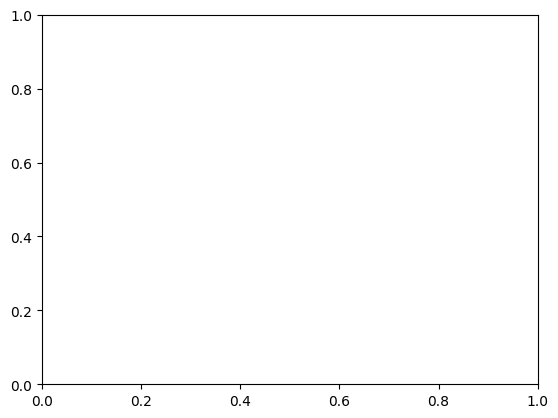

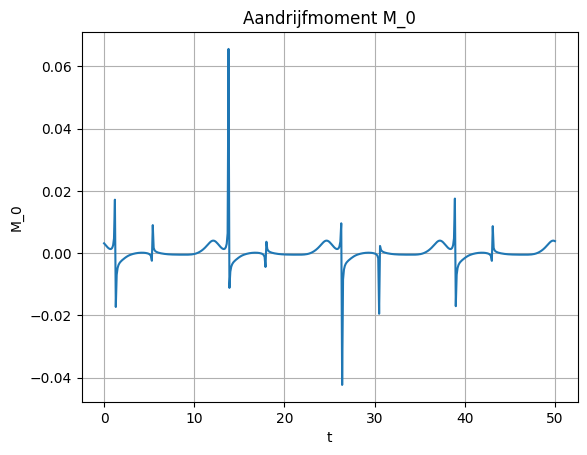

In [138]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(t, M_0)
plt.title("Aandrijfmoment M_0")
plt.xlabel("t")
plt.ylabel("M_0")
plt.grid()
plt.show()

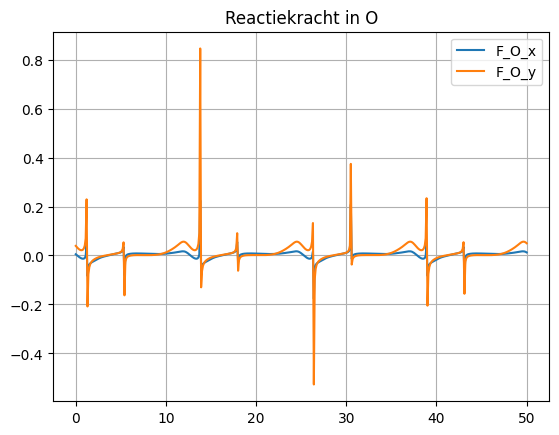

In [139]:
plt.figure()
plt.plot(t, F_O_x, label="F_O_x")
plt.plot(t, F_O_y, label="F_O_y")
plt.legend()
plt.title("Reactiekracht in O")
plt.grid()
plt.show()

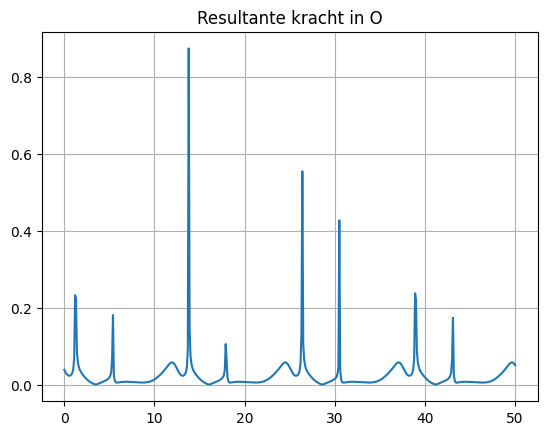

In [140]:
F_O = np.sqrt(F_O_x**2 + F_O_y**2)

plt.figure()
plt.plot(t, F_O)
plt.title("Resultante kracht in O")
plt.grid()
plt.show()